In [5]:
pip install mysql-connector-python pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [7]:
import mysql.connector
import pandas as pd

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="C#$3pPmGCK$%6UY",
    database="hotel_booking"
)

df = pd.read_sql("SELECT * FROM hotel_booking", conn)

conn.close()

print(df.shape)
df.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_21212\915159574.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM hotel_booking", conn)


(119207, 37)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card,row_id
0,Resort Hotel,0,46,2016,March,11,11,0,1,1,...,25.0,0,0,Check-Out,2016-03-12,Allen Edwards,Allen_Edwards@zoho.com,908-134-5296,************3316,1
1,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322,2
2,City Hotel,1,171,2017,April,15,9,2,0,2,...,99.0,0,0,Canceled,2016-10-21,Shannon Krueger,Shannon.K@hotmail.com,289-945-9610,************5381,3
3,Resort Hotel,0,46,2016,March,11,11,0,1,1,...,25.0,0,0,Check-Out,2016-03-12,Kenneth Sullivan,KennethSullivan@gmail.com,482-308-0920,************2039,4
4,City Hotel,1,171,2017,April,15,9,2,0,1,...,109.8,0,2,Canceled,2016-11-13,Connie Brown,ConnieBrown@att.com,117-653-2023,************6791,5


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

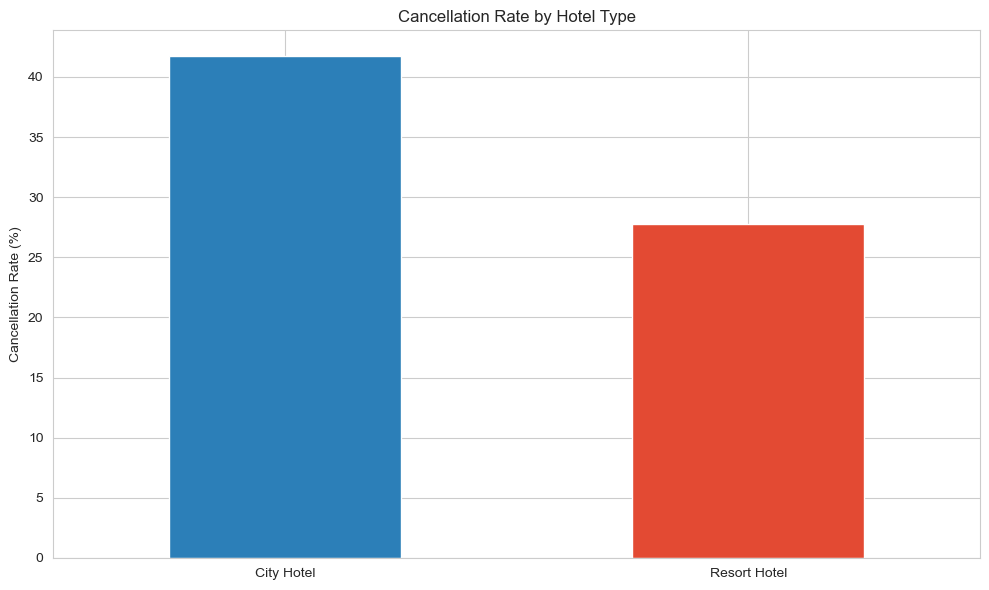

In [10]:
cancel_by_hotel = df.groupby('hotel')['is_canceled'].mean() * 100

plt.figure()
cancel_by_hotel.plot(kind='bar', color=['#2c7fb8', '#e34a33'])
plt.title('Cancellation Rate by Hotel Type')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

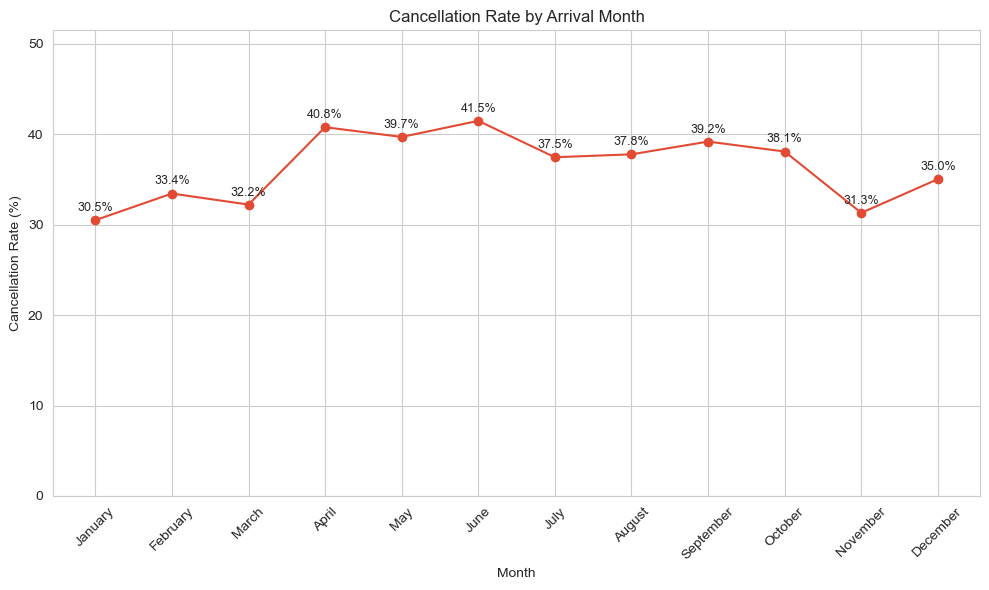

In [12]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

cancel_by_month = df.groupby('arrival_date_month')['is_canceled'].mean().reindex(month_order) * 100

plt.figure()
plt.plot(cancel_by_month.index, cancel_by_month.values, marker='o', color='#e34a33')

for x, y in zip(cancel_by_month.index, cancel_by_month.values):
    plt.text(x, y + 1, f'{y:.1f}%', ha='center', fontsize=9)

plt.title('Cancellation Rate by Arrival Month')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.ylim(0, cancel_by_month.max() + 10)
plt.tight_layout()
plt.show()

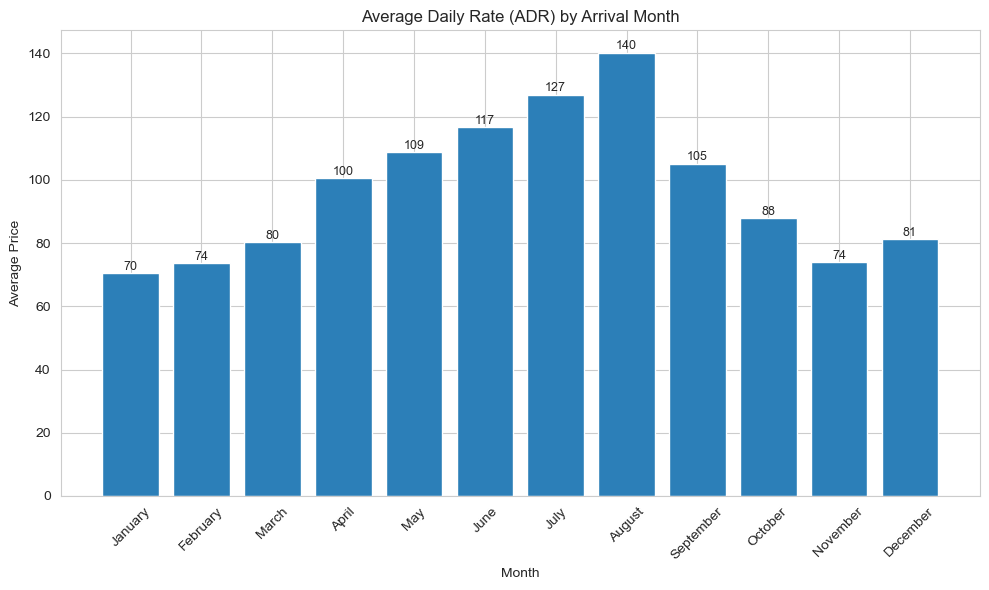

In [13]:
adr_by_month = df.groupby('arrival_date_month')['adr'].mean().reindex(month_order)

plt.figure()
plt.bar(adr_by_month.index, adr_by_month.values, color='#2c7fb8')

for x, y in zip(adr_by_month.index, adr_by_month.values):
    plt.text(x, y + 1, f'{y:.0f}', ha='center', fontsize=9)

plt.title('Average Daily Rate (ADR) by Arrival Month')
plt.ylabel('Average Price')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

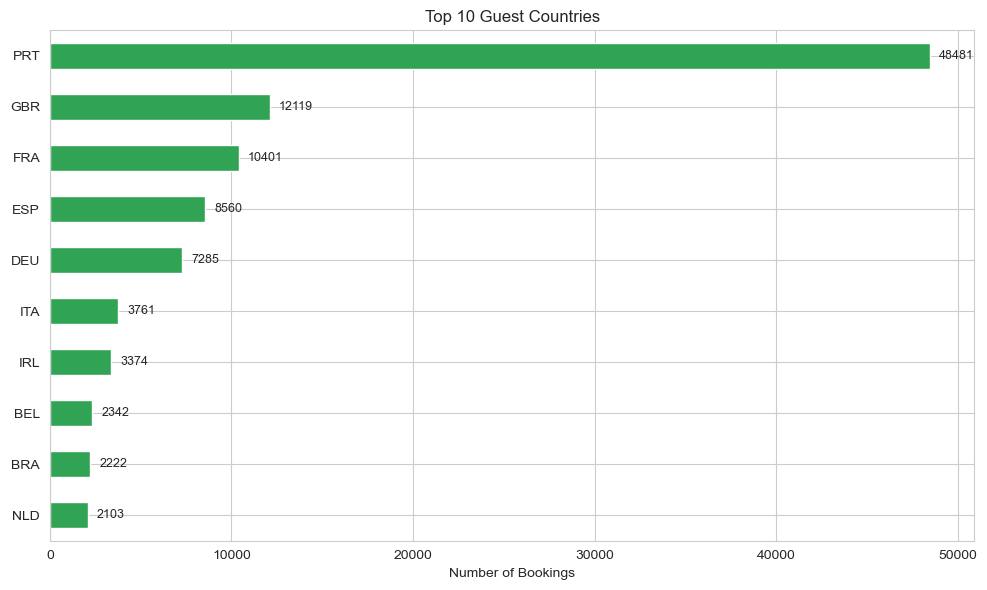

In [15]:
top_countries = df[df['country'] != ''].groupby('country').size().sort_values(ascending=False).head(10)

plt.figure()
top_countries.plot(kind='barh', color='#31a355')
plt.title('Top 10 Guest Countries')
plt.xlabel('Number of Bookings')
plt.ylabel('')
plt.gca().invert_yaxis()

for i, v in enumerate(top_countries.values):
    plt.text(v + 500, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

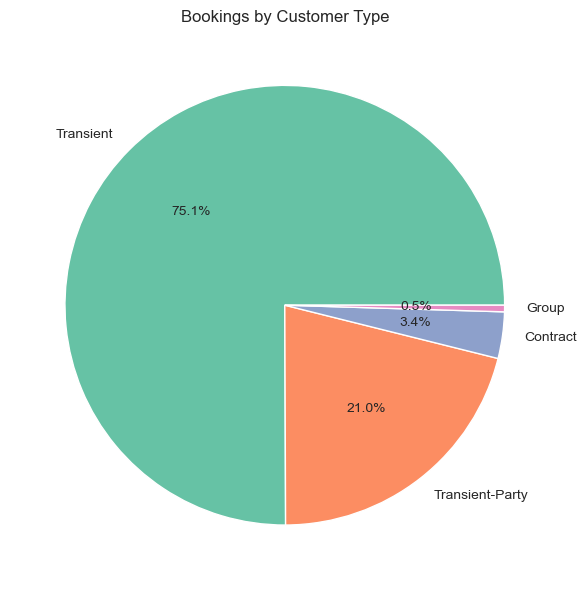

In [16]:
customer_counts = df['customer_type'].value_counts()

plt.figure()
plt.pie(customer_counts.values, labels=customer_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('Set2'))
plt.title('Bookings by Customer Type')
plt.tight_layout()
plt.show()

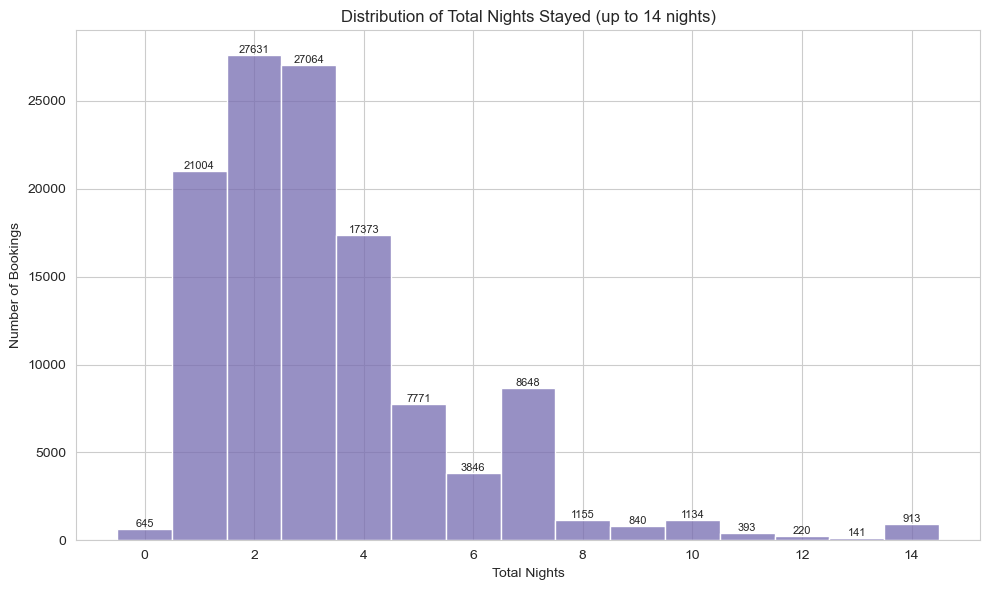

In [20]:
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

plt.figure()
ax = sns.histplot(df[df['total_nights'] <= 14]['total_nights'], bins=14, color='#756bb1', discrete=True)

for container in ax.containers:
    ax.bar_label(container, fontsize=8)

plt.title('Distribution of Total Nights Stayed (up to 14 nights)')
plt.xlabel('Total Nights')
plt.ylabel('Number of Bookings')
plt.tight_layout()
plt.show()

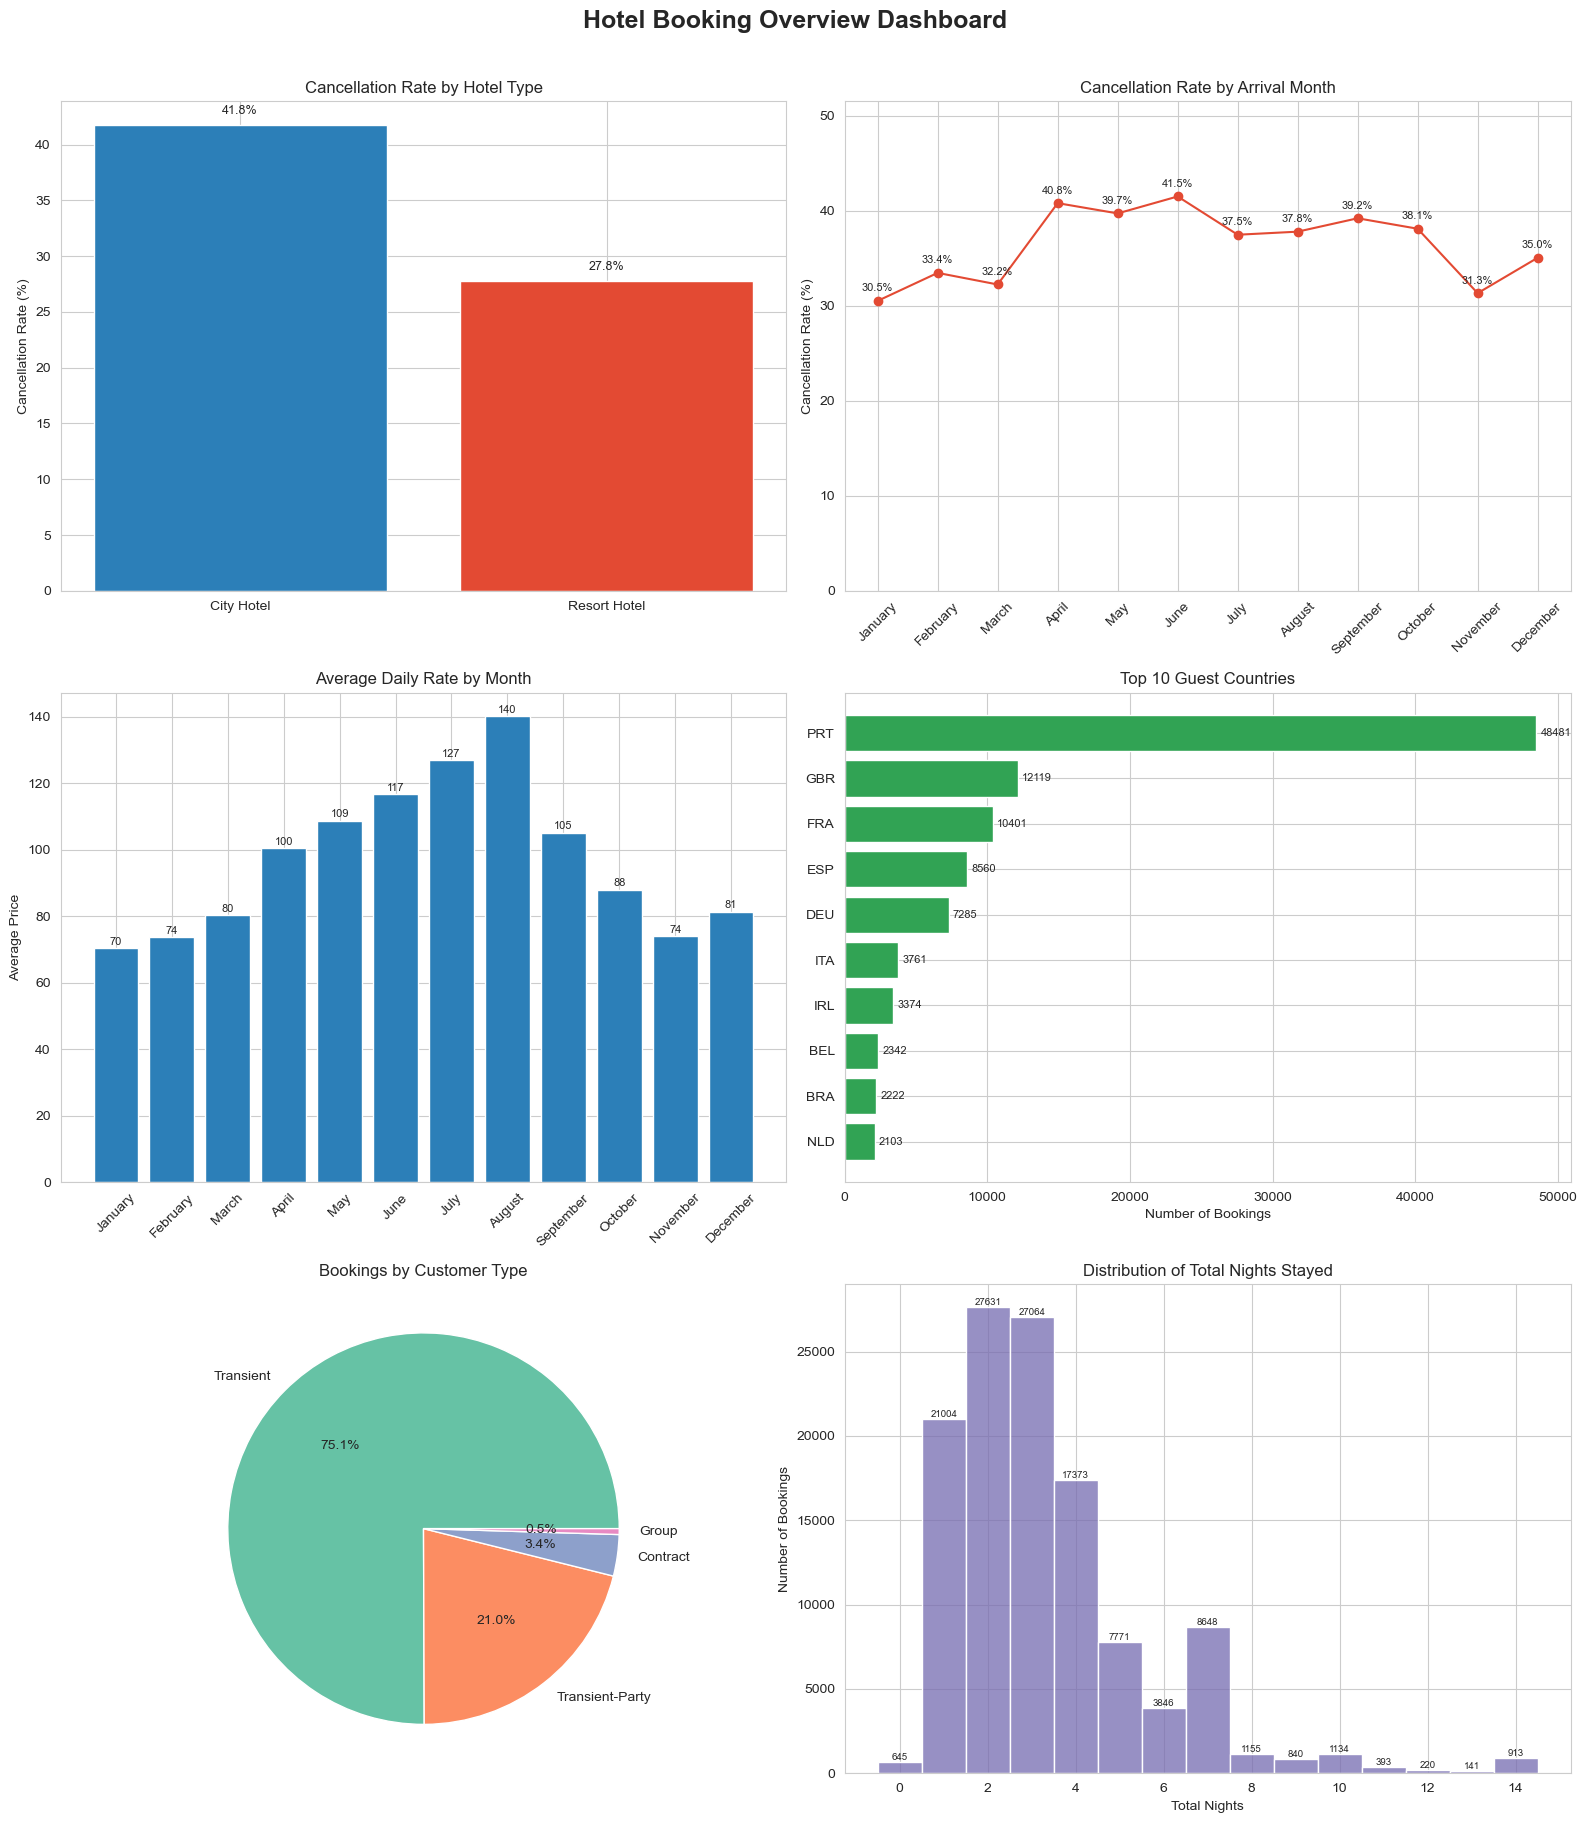

In [22]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# Chart 1: Cancellation rate by hotel
cancel_by_hotel = df.groupby('hotel')['is_canceled'].mean() * 100
axes[0,0].bar(cancel_by_hotel.index, cancel_by_hotel.values, color=['#2c7fb8', '#e34a33'])
for i, v in enumerate(cancel_by_hotel.values):
    axes[0,0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)
axes[0,0].set_title('Cancellation Rate by Hotel Type')
axes[0,0].set_ylabel('Cancellation Rate (%)')

# Chart 2: Cancellation rate by month
cancel_by_month = df.groupby('arrival_date_month')['is_canceled'].mean().reindex(month_order) * 100
axes[0,1].plot(cancel_by_month.index, cancel_by_month.values, marker='o', color='#e34a33')
for x, y in zip(cancel_by_month.index, cancel_by_month.values):
    axes[0,1].text(x, y + 1, f'{y:.1f}%', ha='center', fontsize=8)
axes[0,1].set_title('Cancellation Rate by Arrival Month')
axes[0,1].set_ylabel('Cancellation Rate (%)')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].set_ylim(0, cancel_by_month.max() + 10)

# Chart 3: ADR by month
adr_by_month = df.groupby('arrival_date_month')['adr'].mean().reindex(month_order)
axes[1,0].bar(adr_by_month.index, adr_by_month.values, color='#2c7fb8')
for i, v in enumerate(adr_by_month.values):
    axes[1,0].text(i, v + 1, f'{v:.0f}', ha='center', fontsize=8)
axes[1,0].set_title('Average Daily Rate by Month')
axes[1,0].set_ylabel('Average Price')
axes[1,0].tick_params(axis='x', rotation=45)

# Chart 4: Top 10 countries
top_countries = df[df['country'] != ''].groupby('country').size().sort_values(ascending=False).head(10)
axes[1,1].barh(top_countries.index[::-1], top_countries.values[::-1], color='#31a354')
for i, v in enumerate(top_countries.values[::-1]):
    axes[1,1].text(v + 300, i, str(v), va='center', fontsize=8)
axes[1,1].set_title('Top 10 Guest Countries')
axes[1,1].set_xlabel('Number of Bookings')

# Chart 5: Customer type pie
customer_counts = df['customer_type'].value_counts()
axes[2,0].pie(customer_counts.values, labels=customer_counts.index, autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[2,0].set_title('Bookings by Customer Type')

# Chart 6: Length of stay
sns.histplot(df[df['total_nights'] <= 14]['total_nights'], bins=14, color='#756bb1', discrete=True, ax=axes[2,1])
for container in axes[2,1].containers:
    axes[2,1].bar_label(container, fontsize=7)
axes[2,1].set_title('Distribution of Total Nights Stayed')
axes[2,1].set_xlabel('Total Nights')
axes[2,1].set_ylabel('Number of Bookings')

plt.suptitle('Hotel Booking Overview Dashboard', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('hotel_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
cancel_by_deposit = df.groupby('deposit_type')['is_canceled'].agg(['mean', 'count'])
cancel_by_deposit['mean'] = cancel_by_deposit['mean'] * 100
cancel_by_deposit.columns = ['cancellation_rate_%', 'total_bookings']
print(cancel_by_deposit)

              cancellation_rate_%  total_bookings
deposit_type                                     
No Deposit              28.402259          104460
Non Refund              99.362359           14585
Refundable              22.222222             162


In [24]:
non_refund = df[df['deposit_type'] == 'Non Refund']

print("By market segment:")
print(non_refund['market_segment'].value_counts())
print()
print("By distribution channel:")
print(non_refund['distribution_channel'].value_counts())

By market segment:
market_segment
Groups           9171
Offline TA/TO    5005
Corporate         334
Online TA          56
Direct             19
Name: count, dtype: int64

By distribution channel:
distribution_channel
TA/TO        13649
Corporate      538
Direct         398
Name: count, dtype: int64


In [25]:
groups_df = df[df['market_segment'] == 'Groups']
print(groups_df.groupby('deposit_type')['is_canceled'].agg(['mean', 'count']))

                  mean  count
deposit_type                 
No Deposit    0.283276  10488
Non Refund    0.993240   9171
Refundable    0.100000    130


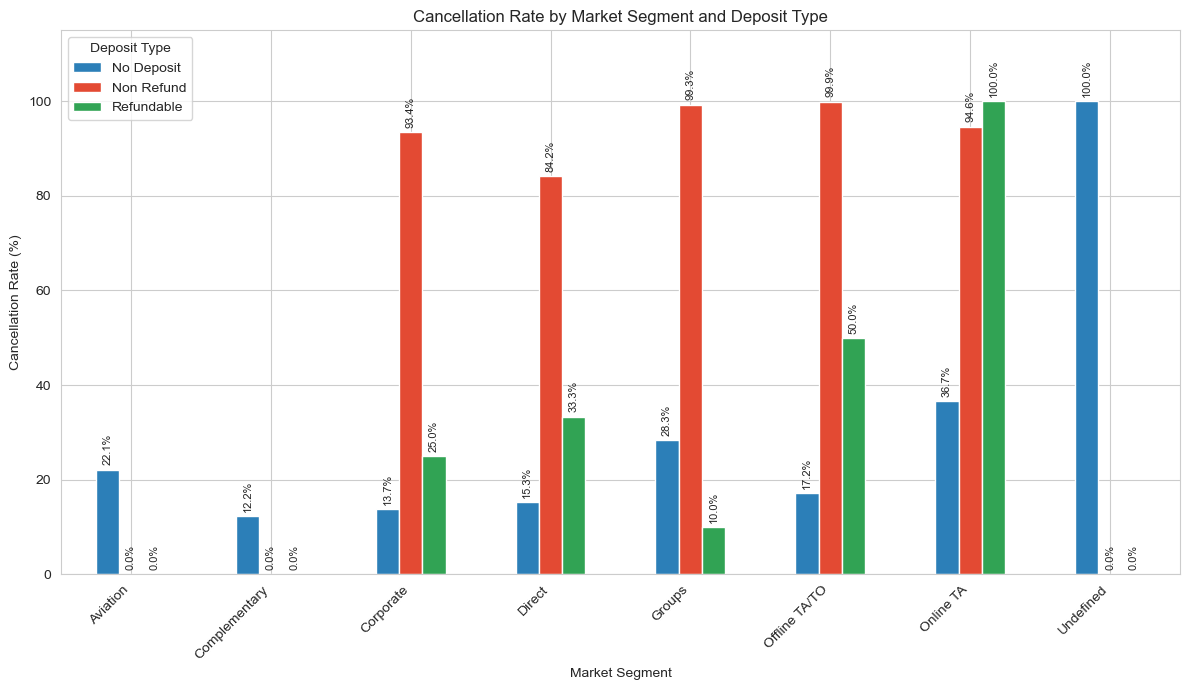

In [27]:
pivot = df.pivot_table(values='is_canceled', index='market_segment', columns='deposit_type', aggfunc='mean') * 100

fig, ax = plt.subplots(figsize=(12, 7))
pivot.plot(kind='bar', ax=ax, color=['#2c7fb8', '#e34a33', '#31a354'])

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8, rotation=90, padding=3)

plt.title('Cancellation Rate by Market Segment and Deposit Type')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Market Segment')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 115)
plt.legend(title='Deposit Type')
plt.tight_layout()
plt.show()

In [28]:
def lead_time_bucket(days):
    if days <= 7:
        return '0-7 days'
    elif days <= 30:
        return '8-30 days'
    elif days <= 90:
        return '31-90 days'
    elif days <= 180:
        return '91-180 days'
    else:
        return '180+ days'

df['lead_time_bucket'] = df['lead_time'].apply(lead_time_bucket)

bucket_order = ['0-7 days', '8-30 days', '31-90 days', '91-180 days', '180+ days']

cancel_by_lead = df.groupby('lead_time_bucket')['is_canceled'].agg(['mean', 'count']).reindex(bucket_order)
cancel_by_lead['mean'] = cancel_by_lead['mean'] * 100
cancel_by_lead.columns = ['cancellation_rate_%', 'total_bookings']
print(cancel_by_lead)

                  cancellation_rate_%  total_bookings
lead_time_bucket                                     
0-7 days                     9.600204           19635
8-30 days                   27.885986           18945
31-90 days                  37.726903           29528
91-180 days                 44.735049           26420
180+ days                   57.012035           24679


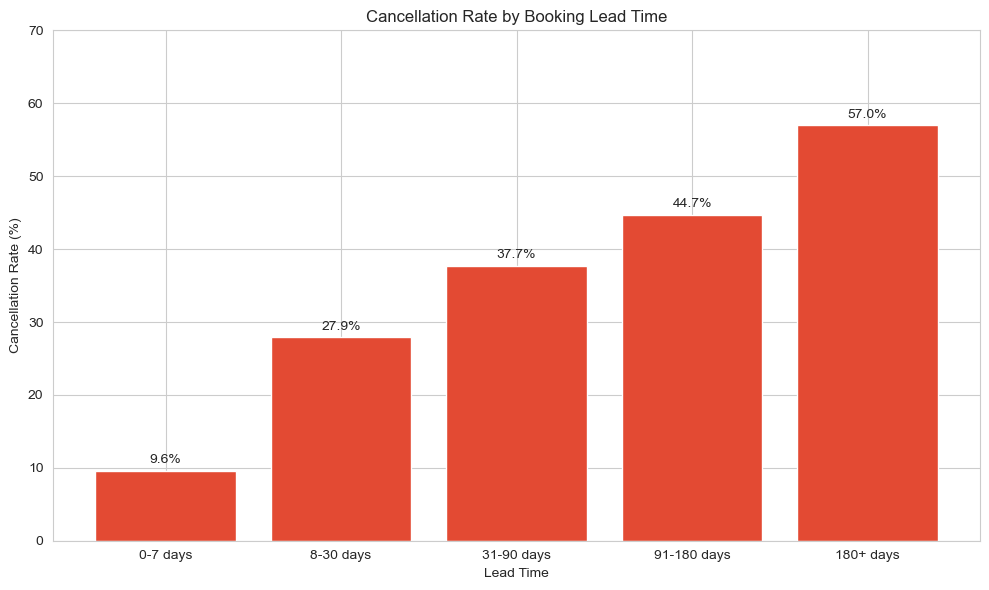

In [29]:
plt.figure(figsize=(10, 6))
bars = plt.bar(cancel_by_lead.index, cancel_by_lead['cancellation_rate_%'], color='#e34a33')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', fontsize=10)

plt.title('Cancellation Rate by Booking Lead Time')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Lead Time')
plt.ylim(0, 70)
plt.tight_layout()
plt.show()

In [30]:
revenue_by_segment = df.groupby('market_segment').agg(
    avg_price=('adr', 'mean'),
    total_bookings=('adr', 'count'),
    cancellation_rate=('is_canceled', 'mean')
)
revenue_by_segment['cancellation_rate'] = revenue_by_segment['cancellation_rate'] * 100
revenue_by_segment = revenue_by_segment.sort_values('avg_price', ascending=False)
print(revenue_by_segment)

                 avg_price  total_bookings  cancellation_rate
market_segment                                               
Online TA       117.318022           56408          36.758970
Direct          115.634595           12582          15.371165
Aviation        100.994383             235          22.127660
Offline TA/TO    87.259609           24181          34.328605
Groups           79.564850           19789          61.109707
Corporate        69.528332            5282          18.761833
Undefined        15.000000               2         100.000000
Complementary     2.945838             728          12.225275


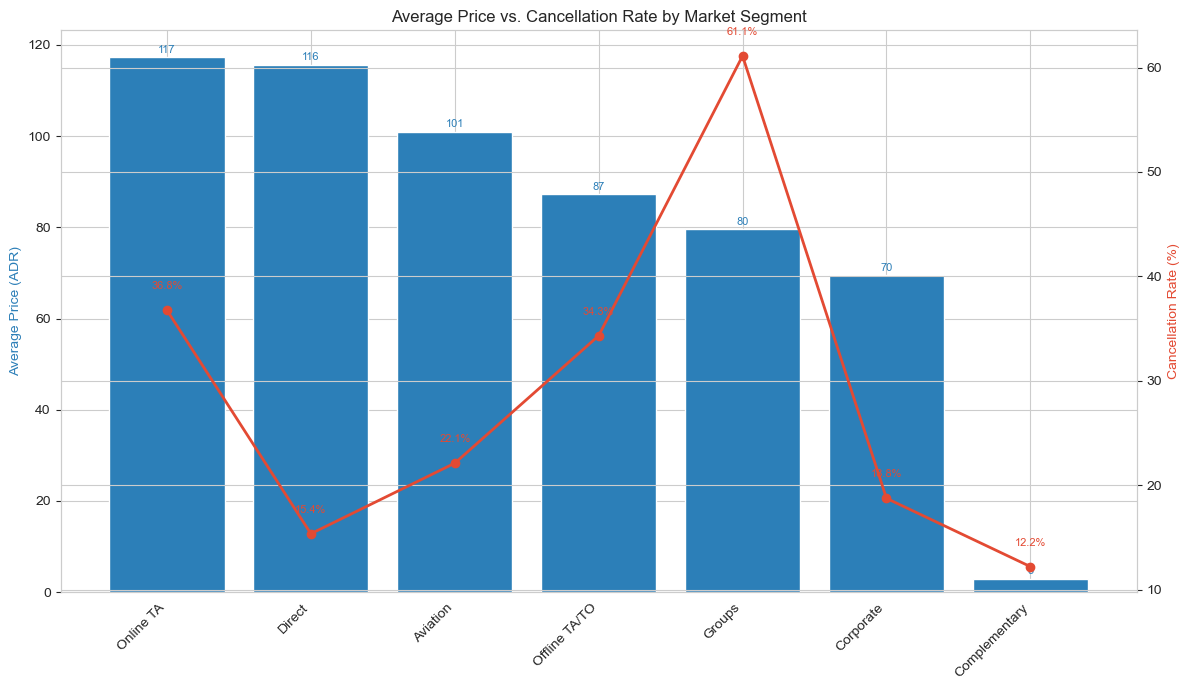

In [31]:
plot_data = revenue_by_segment.drop('Undefined')

fig, ax1 = plt.subplots(figsize=(12, 7))

x = range(len(plot_data))
bars = ax1.bar(x, plot_data['avg_price'], color='#2c7fb8', label='Avg Price')
ax1.set_ylabel('Average Price (ADR)', color='#2c7fb8')
ax1.set_xticks(x)
ax1.set_xticklabels(plot_data.index, rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.0f}', ha='center', fontsize=8, color='#2c7fb8')

ax2 = ax1.twinx()
ax2.plot(x, plot_data['cancellation_rate'], color='#e34a33', marker='o', linewidth=2, label='Cancellation Rate')
ax2.set_ylabel('Cancellation Rate (%)', color='#e34a33')

for i, v in enumerate(plot_data['cancellation_rate']):
    ax2.text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=8, color='#e34a33')

plt.title('Average Price vs. Cancellation Rate by Market Segment')
fig.tight_layout()
plt.show()

In [32]:
df['made_changes'] = df['booking_changes'] > 0

changes_analysis = df.groupby('made_changes')['is_canceled'].agg(['mean', 'count'])
changes_analysis['mean'] = changes_analysis['mean'] * 100
changes_analysis.columns = ['cancellation_rate_%', 'total_bookings']
print(changes_analysis)

              cancellation_rate_%  total_bookings
made_changes                                     
False                   40.864952          101231
True                    15.737650           17976


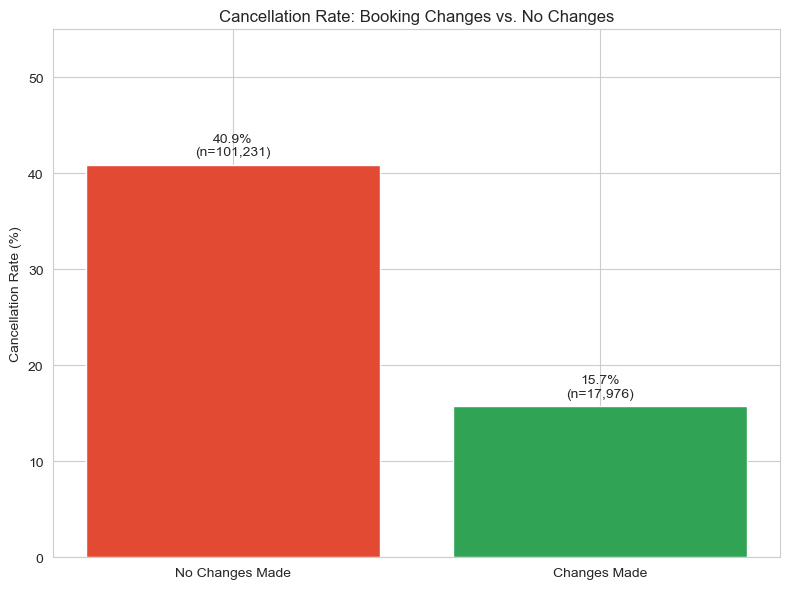

In [33]:
plt.figure(figsize=(8, 6))
labels = ['No Changes Made', 'Changes Made']
values = changes_analysis['cancellation_rate_%'].values
counts = changes_analysis['total_bookings'].values

bars = plt.bar(labels, values, color=['#e34a33', '#31a354'])

for bar, count in zip(bars, counts):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%\n(n={count:,})', ha='center', fontsize=10)

plt.title('Cancellation Rate: Booking Changes vs. No Changes')
plt.ylabel('Cancellation Rate (%)')
plt.ylim(0, 55)
plt.tight_layout()
plt.show()

In [34]:
df['room_mismatch'] = df['reserved_room_type'] != df['assigned_room_type']

mismatch_analysis = df.groupby('room_mismatch')['is_canceled'].agg(['mean', 'count'])
mismatch_analysis['mean'] = mismatch_analysis['mean'] * 100
mismatch_analysis.columns = ['cancellation_rate_%', 'total_bookings']
print(mismatch_analysis)

               cancellation_rate_%  total_bookings
room_mismatch                                     
False                    41.562273          104412
True                      5.413991           14795


In [35]:
print(df.groupby(['is_canceled', 'room_mismatch']).size())

is_canceled  room_mismatch
0            False            61016
             True             13994
1            False            43396
             True               801
dtype: int64


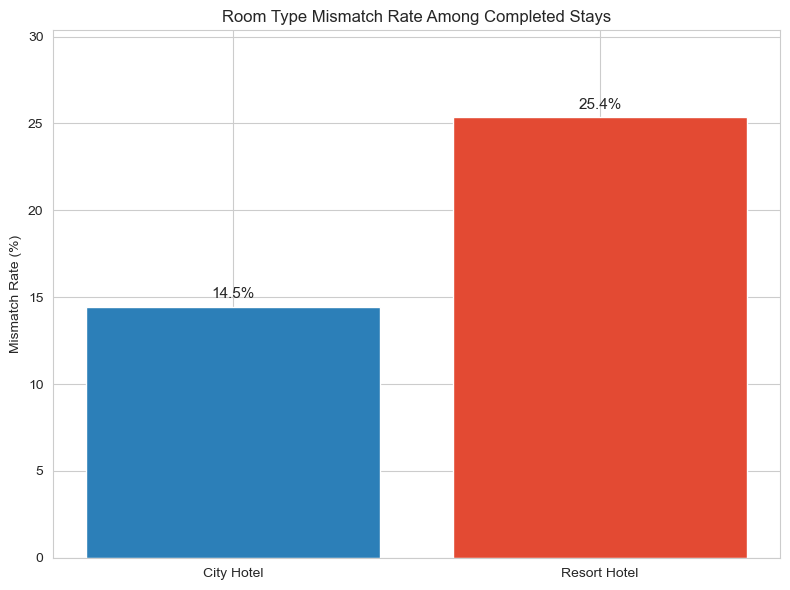

In [36]:
completed = df[df['is_canceled'] == 0]

mismatch_by_hotel = completed.groupby('hotel')['room_mismatch'].mean() * 100

plt.figure(figsize=(8, 6))
bars = plt.bar(mismatch_by_hotel.index, mismatch_by_hotel.values, color=['#2c7fb8', '#e34a33'])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', ha='center', fontsize=11)

plt.title('Room Type Mismatch Rate Among Completed Stays')
plt.ylabel('Mismatch Rate (%)')
plt.xlabel('')
plt.ylim(0, mismatch_by_hotel.max() + 5)
plt.tight_layout()
plt.show()

In [37]:
repeat_analysis = df.groupby('is_repeated_guest').agg(
    cancellation_rate=('is_canceled', 'mean'),
    avg_price=('adr', 'mean'),
    total_bookings=('adr', 'count')
)
repeat_analysis['cancellation_rate'] = repeat_analysis['cancellation_rate'] * 100
print(repeat_analysis)

                   cancellation_rate   avg_price  total_bookings
is_repeated_guest                                               
0                          37.804994  103.113312          115453
1                          14.651039   65.407200            3754


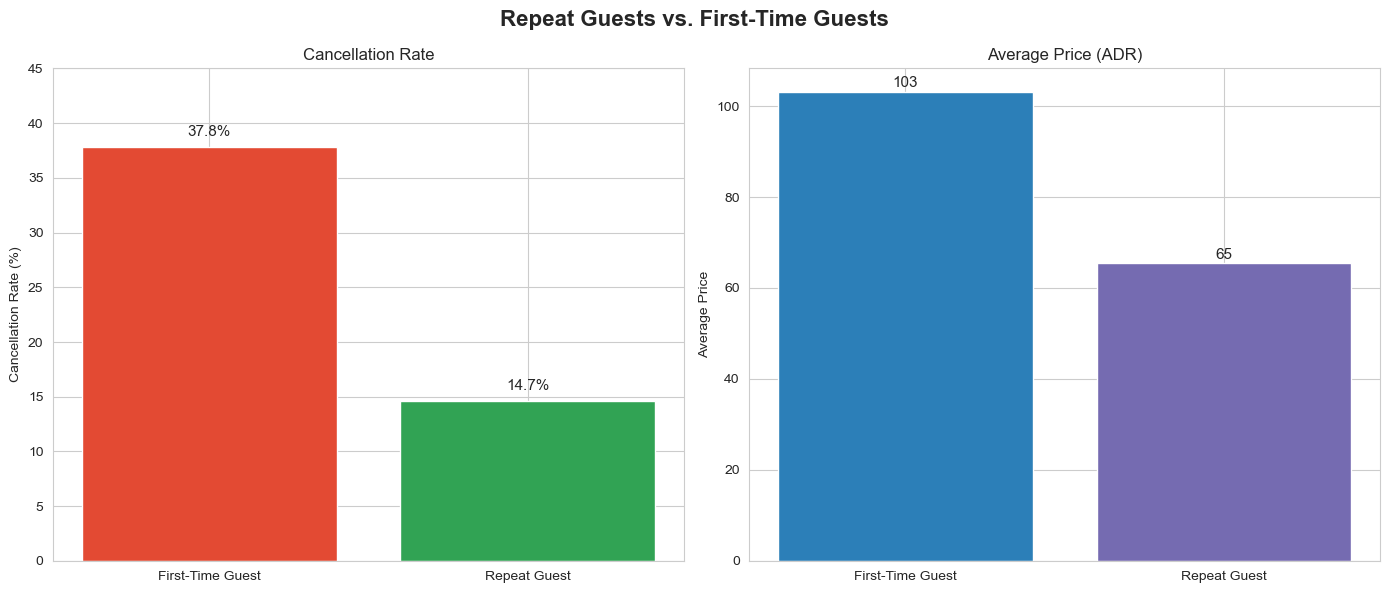

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

labels = ['First-Time Guest', 'Repeat Guest']

bars1 = axes[0].bar(labels, repeat_analysis['cancellation_rate'], color=['#e34a33', '#31a354'])
for bar in bars1:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 1, f'{h:.1f}%', ha='center', fontsize=11)
axes[0].set_title('Cancellation Rate')
axes[0].set_ylabel('Cancellation Rate (%)')
axes[0].set_ylim(0, 45)

bars2 = axes[1].bar(labels, repeat_analysis['avg_price'], color=['#2c7fb8', '#756bb1'])
for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 1, f'{h:.0f}', ha='center', fontsize=11)
axes[1].set_title('Average Price (ADR)')
axes[1].set_ylabel('Average Price')

plt.suptitle('Repeat Guests vs. First-Time Guests', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [39]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

bookings_month_hotel = df.groupby(['arrival_date_month', 'hotel']).size().unstack()
bookings_month_hotel = bookings_month_hotel.reindex(month_order)
print(bookings_month_hotel)

hotel               City Hotel  Resort Hotel
arrival_date_month                          
January                   3730          2191
February                  4950          3102
March                     6433          3333
April                     7469          3609
May                       8221          3559
June                      7885          3044
July                      8070          4573
August                    8967          4894
September                 7392          3108
October                   7594          3553
November                  4336          2435
December                  4114          2645


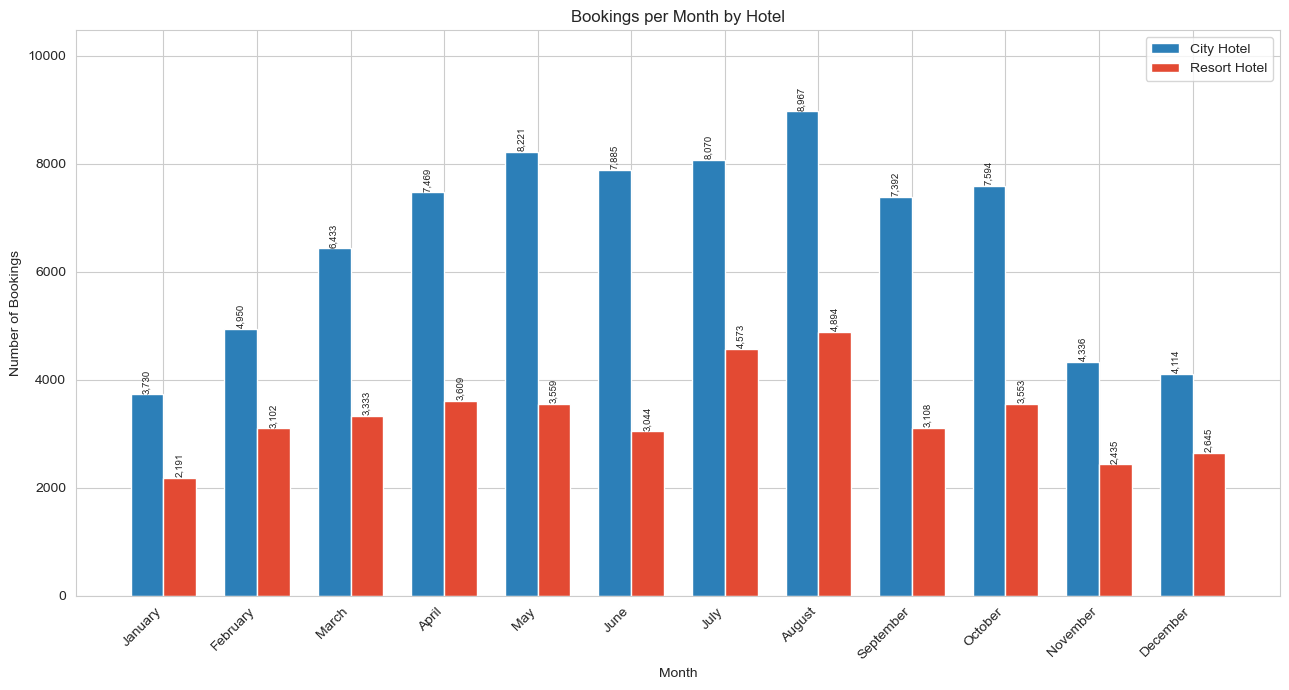

In [40]:
plt.figure(figsize=(13, 7))

x = range(len(bookings_month_hotel))
width = 0.35

bars1 = plt.bar([i - width/2 for i in x], bookings_month_hotel['City Hotel'], width, label='City Hotel', color='#2c7fb8')
bars2 = plt.bar([i + width/2 for i in x], bookings_month_hotel['Resort Hotel'], width, label='Resort Hotel', color='#e34a33')

for bar in bars1:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 50, f'{h:,}', ha='center', fontsize=7, rotation=90)
for bar in bars2:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 50, f'{h:,}', ha='center', fontsize=7, rotation=90)

plt.title('Bookings per Month by Hotel')
plt.ylabel('Number of Bookings')
plt.xlabel('Month')
plt.xticks(x, bookings_month_hotel.index, rotation=45, ha='right')
plt.legend()
plt.ylim(0, bookings_month_hotel.values.max() + 1500)
plt.tight_layout()
plt.show()

In [41]:
bookings_year_hotel = df.groupby(['arrival_date_year', 'hotel']).size().unstack()
print(bookings_year_hotel)

hotel              City Hotel  Resort Hotel
arrival_date_year                          
2015                    13657          8309
2016                    38058         18564
2017                    27446         13173


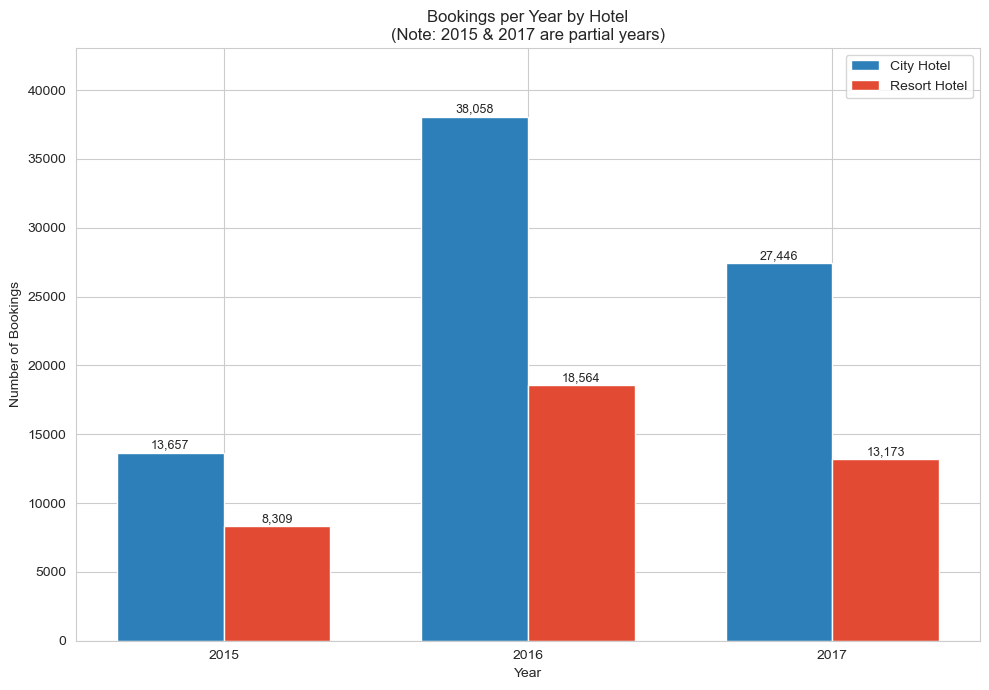

In [42]:
plt.figure(figsize=(10, 7))

x = range(len(bookings_year_hotel))
width = 0.35

bars1 = plt.bar([i - width/2 for i in x], bookings_year_hotel['City Hotel'], width, label='City Hotel', color='#2c7fb8')
bars2 = plt.bar([i + width/2 for i in x], bookings_year_hotel['Resort Hotel'], width, label='Resort Hotel', color='#e34a33')

for bar in bars1:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 300, f'{h:,}', ha='center', fontsize=9)
for bar in bars2:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 300, f'{h:,}', ha='center', fontsize=9)

plt.title('Bookings per Year by Hotel\n(Note: 2015 & 2017 are partial years)')
plt.ylabel('Number of Bookings')
plt.xlabel('Year')
plt.xticks(x, bookings_year_hotel.index)
plt.legend()
plt.ylim(0, bookings_year_hotel.values.max() + 5000)
plt.tight_layout()
plt.show()

In [43]:
total_bookings = df['hotel'].value_counts()
print(total_bookings)

hotel
City Hotel      79161
Resort Hotel    40046
Name: count, dtype: int64


In [44]:
cancel_rate = df.groupby('hotel')['is_canceled'].mean() * 100
print(cancel_rate)

hotel
City Hotel      41.784465
Resort Hotel    27.768067
Name: is_canceled, dtype: float64


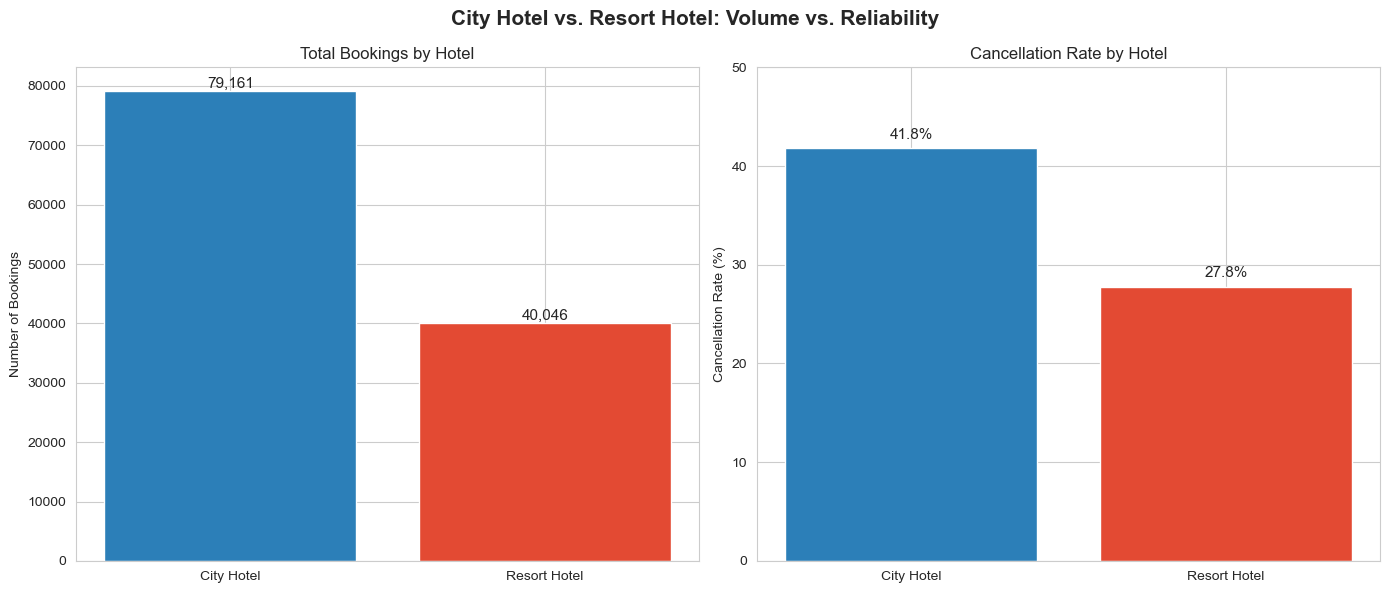

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

hotels = ['City Hotel', 'Resort Hotel']

bars1 = axes[0].bar(hotels, total_bookings.values, color=['#2c7fb8', '#e34a33'])
for bar in bars1:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 500, f'{h:,}', ha='center', fontsize=11)
axes[0].set_title('Total Bookings by Hotel')
axes[0].set_ylabel('Number of Bookings')

bars2 = axes[1].bar(hotels, cancel_rate.values, color=['#2c7fb8', '#e34a33'])
for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 1, f'{h:.1f}%', ha='center', fontsize=11)
axes[1].set_title('Cancellation Rate by Hotel')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].set_ylim(0, 50)

plt.suptitle('City Hotel vs. Resort Hotel: Volume vs. Reliability', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [46]:
city_top10 = df[df['hotel'] == 'City Hotel'].groupby(['name', 'email']).size().sort_values(ascending=False).head(10)
print(city_top10)

name              email                      
James Smith       James.Smith@yahoo.com          3
Michael Gonzalez  MichaelGonzalez@comcast.net    3
Anthony Miller    Anthony_Miller@yandex.com      2
Amanda Hart       Hart_Amanda@comcast.net        2
Jessica Davis     Jessica_D@gmail.com            2
Carrie Gonzalez   CarrieGonzalez@yandex.com      2
Jennifer Fisher   Jennifer.F@att.com             2
John Johnson      John.Johnson@zoho.com          2
James Sanders     Sanders_James@outlook.com      2
Terri Johnson     Terri.Johnson@hotmail.com      2
dtype: int64


In [47]:
resort_top10 = df[df['hotel'] == 'Resort Hotel'].groupby(['name', 'email']).size().sort_values(ascending=False).head(10)
print(resort_top10)

name                email                       
Melinda Lee         Lee_Melinda@mail.com            2
Brian Williams      Williams.Brian@yahoo.com        2
Stephanie Smith     Stephanie.S@gmail.com           2
Amy White           AmyWhite@comcast.net            2
Jennifer King       JKing@gmail.com                 2
Catherine Lopez     Catherine.L@zoho.com            2
Brian Brown         Brian.B@comcast.net             2
Christopher Miller  Christopher_M@yandex.com        2
Margaret Cook       Cook_Margaret@protonmail.com    2
Daniel Harris       DHarris@protonmail.com          2
dtype: int64


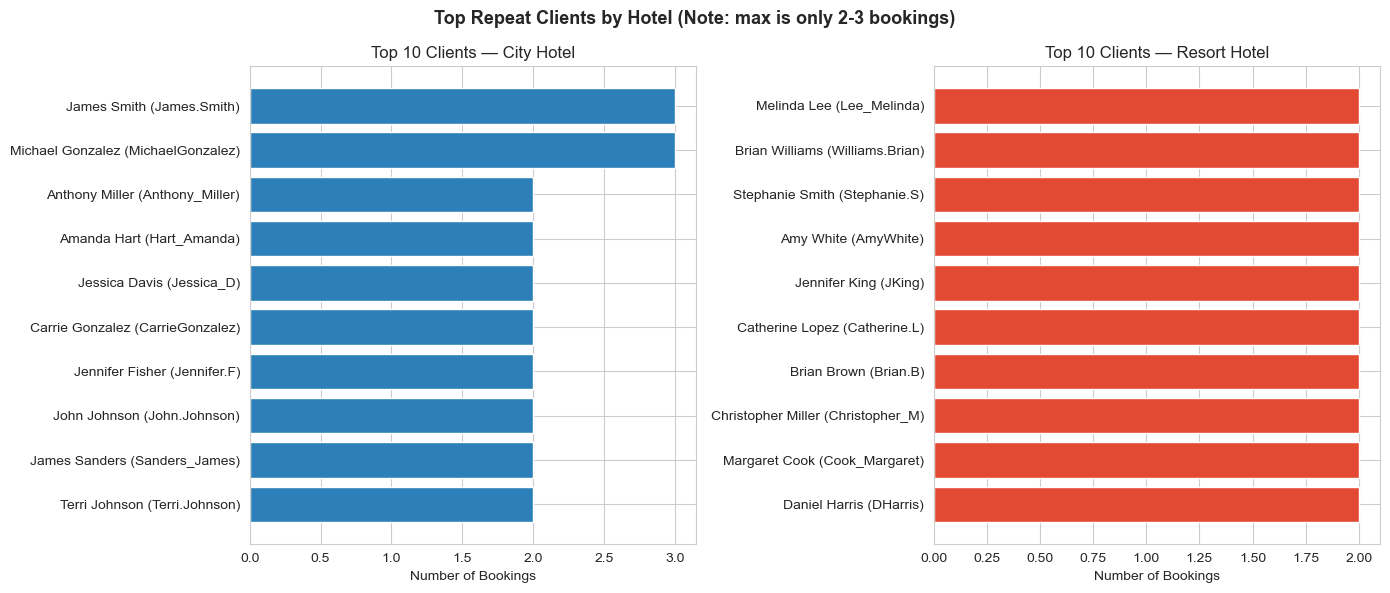

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh([f"{n} ({e.split('@')[0]})" for n, e in city_top10.index], city_top10.values, color='#2c7fb8')
axes[0].set_title('Top 10 Clients — City Hotel')
axes[0].set_xlabel('Number of Bookings')
axes[0].invert_yaxis()

axes[1].barh([f"{n} ({e.split('@')[0]})" for n, e in resort_top10.index], resort_top10.values, color='#e34a33')
axes[1].set_title('Top 10 Clients — Resort Hotel')
axes[1].set_xlabel('Number of Bookings')
axes[1].invert_yaxis()

plt.suptitle('Top Repeat Clients by Hotel (Note: max is only 2-3 bookings)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [49]:
status_overall = df['reservation_status'].value_counts()
status_pct = df['reservation_status'].value_counts(normalize=True) * 100

print("Counts:")
print(status_overall)
print()
print("Percentages:")
print(status_pct.round(1))

Counts:
reservation_status
Check-Out    75010
Canceled     42991
No-Show       1206
Name: count, dtype: int64

Percentages:
reservation_status
Check-Out    62.9
Canceled     36.1
No-Show       1.0
Name: proportion, dtype: float64


In [50]:
status_by_hotel = df.groupby(['hotel', 'reservation_status']).size().unstack()
status_by_hotel_pct = df.groupby('hotel')['reservation_status'].value_counts(normalize=True).unstack() * 100
print(status_by_hotel)
print()
print(status_by_hotel_pct.round(1))

reservation_status  Canceled  Check-Out  No-Show
hotel                                           
City Hotel             32162      46084      915
Resort Hotel           10829      28926      291

reservation_status  Canceled  Check-Out  No-Show
hotel                                           
City Hotel              40.6       58.2      1.2
Resort Hotel            27.0       72.2      0.7


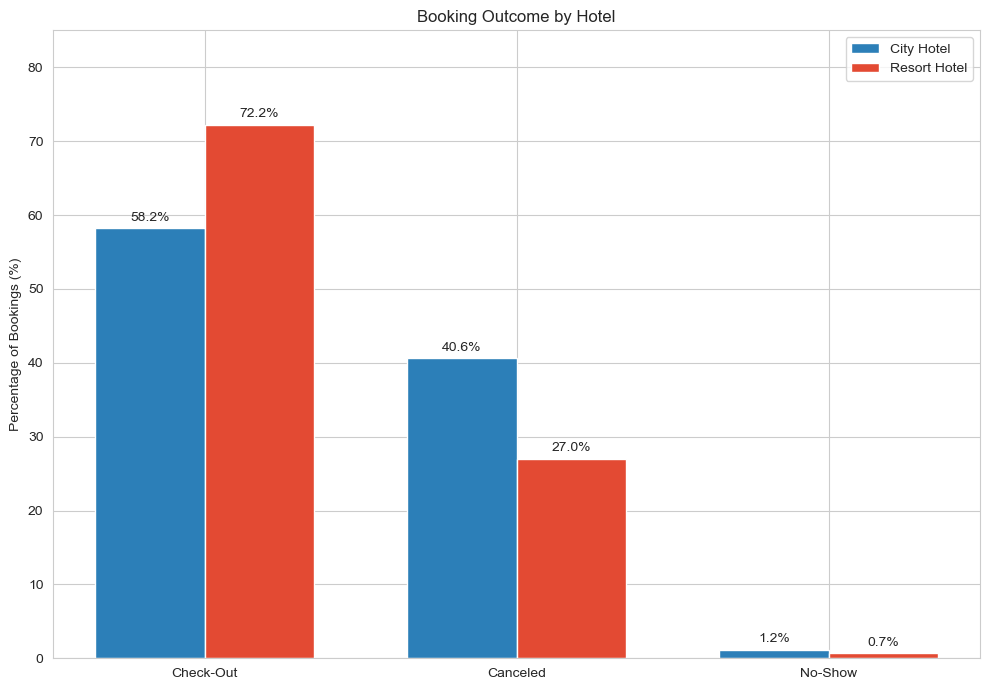

In [58]:
plt.figure(figsize=(10, 7))

statuses = ['Check-Out', 'Canceled', 'No-Show']
city_vals = [status_by_hotel_pct.loc['City Hotel', s] for s in statuses]
resort_vals = [status_by_hotel_pct.loc['Resort Hotel', s] for s in statuses]

x = range(len(statuses))
width = 0.35

bars1 = plt.bar([i - width/2 for i in x], city_vals, width, label='City Hotel', color='#2c7fb8')
bars2 = plt.bar([i + width/2 for i in x], resort_vals, width, label='Resort Hotel', color='#e34a33')

for bar in bars1:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 1, f'{h:.1f}%', ha='center', fontsize=10)
for bar in bars2:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 1, f'{h:.1f}%', ha='center', fontsize=10)

plt.title('Booking Outcome by Hotel')
plt.ylabel('Percentage of Bookings (%)')
plt.xticks(x, statuses)
plt.legend()
plt.ylim(0, 85)
plt.tight_layout()
plt.show()

In [52]:
channel_overall = df['distribution_channel'].value_counts()
channel_pct = df['distribution_channel'].value_counts(normalize=True) * 100

print("Counts:")
print(channel_overall)
print()
print("Percentages:")
print(channel_pct.round(1))

Counts:
distribution_channel
TA/TO        97748
Direct       14610
Corporate     6651
GDS            193
Undefined        5
Name: count, dtype: int64

Percentages:
distribution_channel
TA/TO        82.0
Direct       12.3
Corporate     5.6
GDS           0.2
Undefined     0.0
Name: proportion, dtype: float64


In [53]:
channel_by_hotel = df.groupby(['hotel', 'distribution_channel']).size().unstack()
print(channel_by_hotel)

distribution_channel  Corporate  Direct    GDS    TA/TO  Undefined
hotel                                                             
City Hotel               3386.0  6749.0  193.0  68829.0        4.0
Resort Hotel             3265.0  7861.0    NaN  28919.0        1.0


In [54]:
channel_by_hotel = df.groupby(['hotel', 'distribution_channel']).size().unstack().fillna(0).astype(int)
print(channel_by_hotel)

distribution_channel  Corporate  Direct  GDS  TA/TO  Undefined
hotel                                                         
City Hotel                 3386    6749  193  68829          4
Resort Hotel               3265    7861    0  28919          1


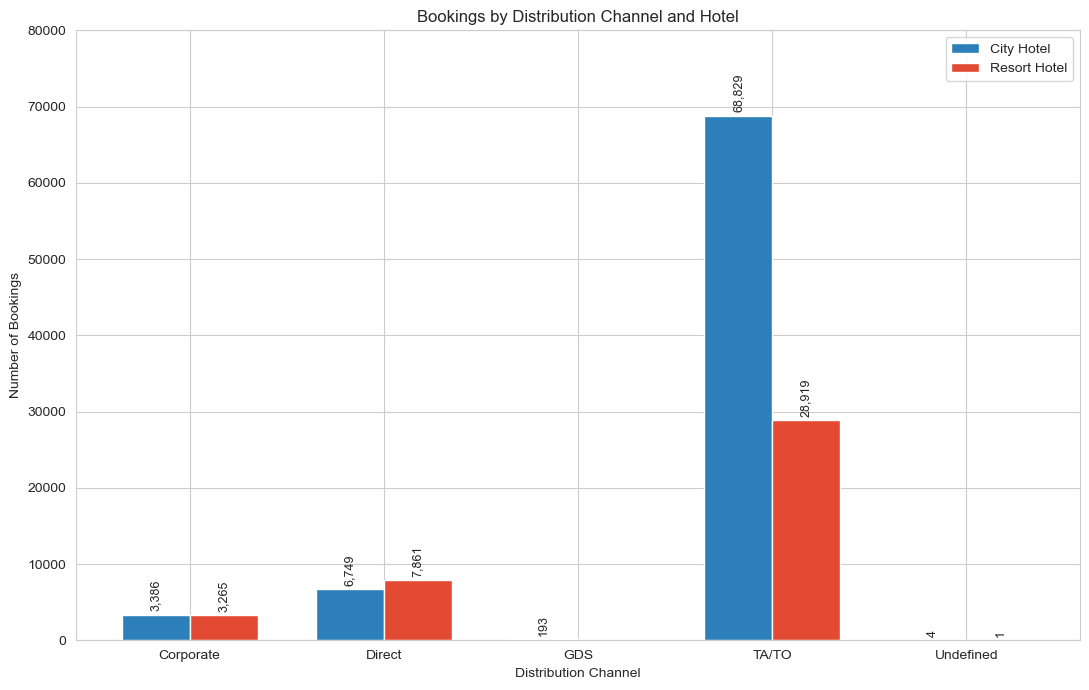

In [55]:
plt.figure(figsize=(11, 7))

channels = ['Corporate', 'Direct', 'GDS', 'TA/TO', 'Undefined']
city_vals = channel_by_hotel.loc['City Hotel', channels].values
resort_vals = channel_by_hotel.loc['Resort Hotel', channels].values

x = range(len(channels))
width = 0.35

bars1 = plt.bar([i - width/2 for i in x], city_vals, width, label='City Hotel', color='#2c7fb8')
bars2 = plt.bar([i + width/2 for i in x], resort_vals, width, label='Resort Hotel', color='#e34a33')

for bar in bars1:
    h = bar.get_height()
    if h > 0:
        plt.text(bar.get_x() + bar.get_width()/2, h + 800, f'{h:,.0f}', ha='center', fontsize=9, rotation=90)
for bar in bars2:
    h = bar.get_height()
    if h > 0:
        plt.text(bar.get_x() + bar.get_width()/2, h + 800, f'{h:,.0f}', ha='center', fontsize=9, rotation=90)

plt.title('Bookings by Distribution Channel and Hotel')
plt.ylabel('Number of Bookings')
plt.xlabel('Distribution Channel')
plt.xticks(x, channels)
plt.legend()
plt.ylim(0, 80000)
plt.tight_layout()
plt.show()

In [56]:
meal_by_hotel = df.groupby(['hotel', 'meal']).size().unstack().fillna(0).astype(int)
print(meal_by_hotel)

print()
meal_by_hotel_pct = df.groupby('hotel')['meal'].value_counts(normalize=True).unstack().fillna(0) * 100
print(meal_by_hotel_pct.round(1))

meal             BB   FB    HB     SC  Undefined
hotel                                           
City Hotel    62231   44  6412  10474          0
Resort Hotel  30002  754  8046     75       1169

meal            BB   FB    HB    SC  Undefined
hotel                                         
City Hotel    78.6  0.1   8.1  13.2        0.0
Resort Hotel  74.9  1.9  20.1   0.2        2.9


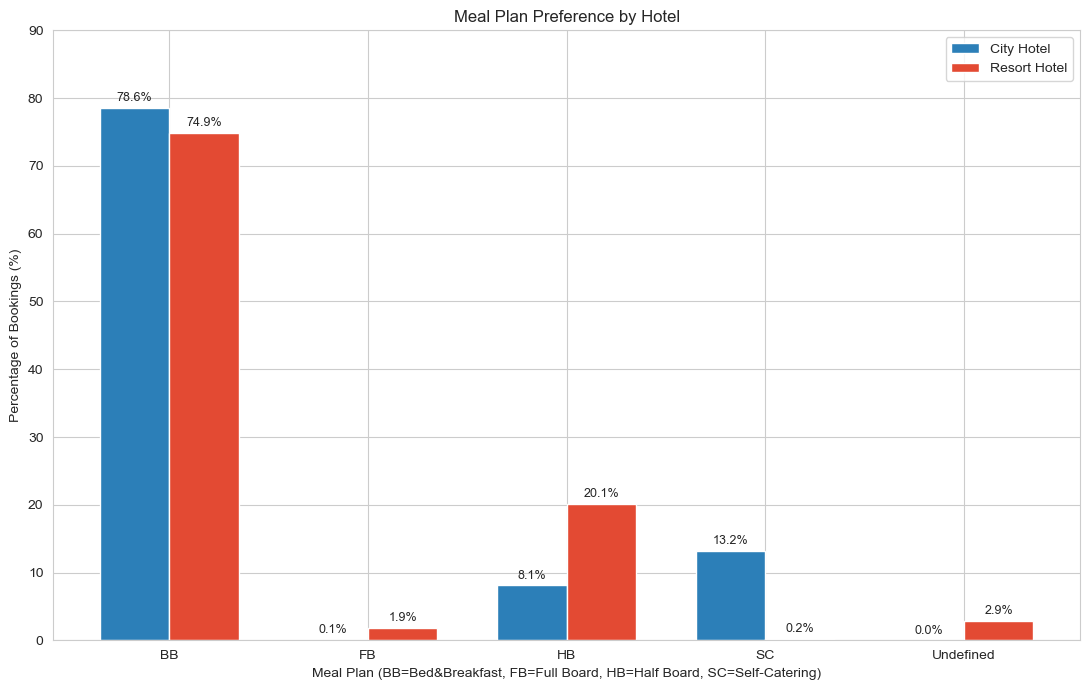

In [57]:
plt.figure(figsize=(11, 7))

meals = ['BB', 'FB', 'HB', 'SC', 'Undefined']
city_vals = meal_by_hotel_pct.loc['City Hotel', meals].values
resort_vals = meal_by_hotel_pct.loc['Resort Hotel', meals].values

x = range(len(meals))
width = 0.35

bars1 = plt.bar([i - width/2 for i in x], city_vals, width, label='City Hotel', color='#2c7fb8')
bars2 = plt.bar([i + width/2 for i in x], resort_vals, width, label='Resort Hotel', color='#e34a33')

for bar in bars1:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 1, f'{h:.1f}%', ha='center', fontsize=9)
for bar in bars2:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 1, f'{h:.1f}%', ha='center', fontsize=9)

plt.title('Meal Plan Preference by Hotel')
plt.ylabel('Percentage of Bookings (%)')
plt.xlabel('Meal Plan (BB=Bed&Breakfast, FB=Full Board, HB=Half Board, SC=Self-Catering)')
plt.xticks(x, meals)
plt.legend()
plt.ylim(0, 90)
plt.tight_layout()
plt.show()

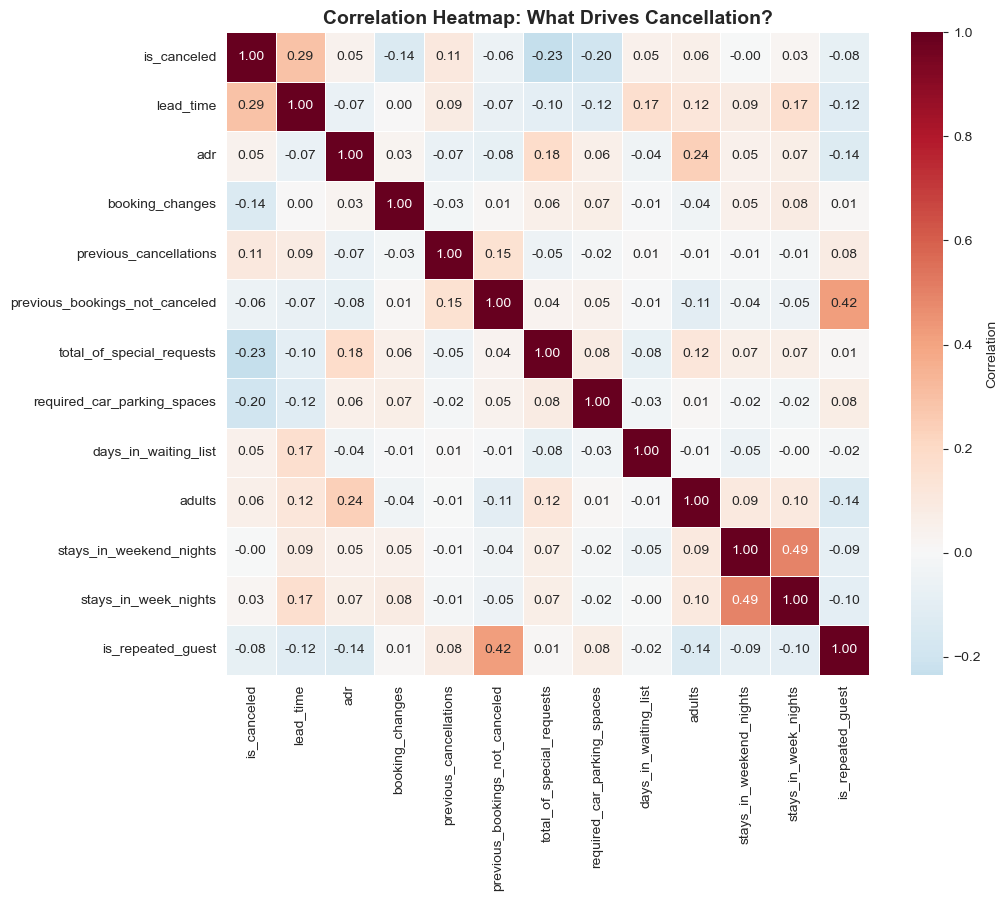

In [59]:
numeric_cols = ['is_canceled', 'lead_time', 'adr', 'booking_changes', 'previous_cancellations',
                 'previous_bookings_not_canceled', 'total_of_special_requests', 
                 'required_car_parking_spaces', 'days_in_waiting_list', 'adults', 
                 'stays_in_weekend_nights', 'stays_in_week_nights', 'is_repeated_guest']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap: What Drives Cancellation?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()